# 08 – Robustness to Scientific Definitions and Measurement Uncertainty
## Objective

This notebook tests whether the conclusions of the machine-learning analysis remain stable when reasonable scientific assumptions are changed slightly.

The analysis investigates two sources of uncertainty:

1. **Target-definition uncertainty**  
   Whether conclusions change when the radius threshold used to define a gas giant is slightly modified.

2. **Measurement uncertainty**  
   Whether predictions change when the measured host-star properties are perturbed slightly.

The central question is:

> Would the scientific conclusions change if the target definition or measured stellar properties changed slightly?

The notebook is divided into three parts:

1. Alternative target definitions
2. Feature perturbation
3. Stability versus prediction confidence

These analyses do not replace the original target definition or the selected Random Forest model.

Instead, they test the robustness of the conclusions obtained using those choices.

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [2]:
RANDOM_STATE = 42

FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

TARGET_FEATURE = "pl_rade"

N_SPLITS = 5

THRESHOLDS = {
    "Lower Threshold": 8.0,
    "Original Threshold": 10.0,
    "Higher Threshold": 12.0
}

In [3]:
ml_ready_dataset = pd.read_csv(
    "../data/processed/ml_ready_dataset.csv"
)

print(
    "Dataset shape:",
    ml_ready_dataset.shape
)

print(
    "Available planetary radius column:",
    TARGET_FEATURE in ml_ready_dataset.columns
)

Dataset shape: (39954, 50)
Available planetary radius column: True


In [4]:
best_model = joblib.load(
    "../models/random_forest.joblib"
)

final_rf = best_model.named_steps[
    "model"
]

final_rf_parameters = {
    parameter: value
    for parameter, value in final_rf.get_params().items()
    if parameter in [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "class_weight",
        "random_state"
    ]
}

final_rf_parameters

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100,
 'random_state': 42}

In [5]:
robustness_data = ml_ready_dataset[
    FEATURES + [
        TARGET_FEATURE
    ]
].copy()

robustness_data.head()

,st_teff,st_rad,st_met,pl_rade
0,4874.0,13.76,-0.26,NaN
1,4742.0,19.00,-0.35,NaN
2,NaN,NaN,NaN,NaN
3,4213.0,29.79,-0.02,NaN
4,NaN,NaN,NaN,NaN


In [6]:
print(
    robustness_data.isna().sum()
)

st_teff     3603
st_rad      3412
st_met     14928
pl_rade    12414
dtype: int64


# Alternative Target Definitions

The original analysis defines a gas giant using a specific planetary-radius threshold.

However, the exact boundary between a gas giant and a non-gas giant is a scientific modeling choice.

To test the robustness of the conclusions, three nearby thresholds are evaluated:

- A lower threshold
- The original threshold
- A higher threshold

For each threshold:

1. The target labels are recalculated.
2. Class balance is examined.
3. The fixed Random Forest configuration is retrained.
4. Cross-validation performance is evaluated.
5. Feature importance is examined.

The key question is:

> Do the scientific conclusions remain broadly similar when the target boundary changes reasonably?

In [7]:
target_datasets = {}

for threshold_name, threshold_value in THRESHOLDS.items():

    threshold_data = robustness_data.copy()

    threshold_data[
        "gas_giant"
    ] = (
        threshold_data[
            TARGET_FEATURE
        ]
        >= threshold_value
    ).astype(int)

    target_datasets[
        threshold_name
    ] = threshold_data

    print(
        threshold_name,
        "| Threshold:",
        threshold_value,
        "| Gas Giants:",
        threshold_data[
            "gas_giant"
        ].sum(),
        "| Total:",
        len(threshold_data)
    )

Lower Threshold | Threshold: 8.0 | Gas Giants: 3574 | Total: 39954
Original Threshold | Threshold: 10.0 | Gas Giants: 3046 | Total: 39954
Higher Threshold | Threshold: 12.0 | Gas Giants: 2238 | Total: 39954


In [8]:
class_balance_results = []

for threshold_name, threshold_data in target_datasets.items():

    class_counts = (
        threshold_data[
            "gas_giant"
        ]
        .value_counts()
        .sort_index()
    )

    class_balance_results.append({
        "Threshold": threshold_name,
        "Radius Threshold": THRESHOLDS[
            threshold_name
        ],
        "Non-Gas Giants": class_counts.get(
            0,
            0
        ),
        "Gas Giants": class_counts.get(
            1,
            0
        ),
        "Gas-Giant Percentage":
            threshold_data[
                "gas_giant"
            ].mean()
            * 100
    })

class_balance_results = pd.DataFrame(
    class_balance_results
)

class_balance_results.round(3)

,Threshold,Radius Threshold,Non-Gas Giants,Gas Giants,Gas-Giant Percentage
0,Lower Threshold,8.0,36380,3574,8.945
1,Original Threshold,10.0,36908,3046,7.624
2,Higher Threshold,12.0,37716,2238,5.601


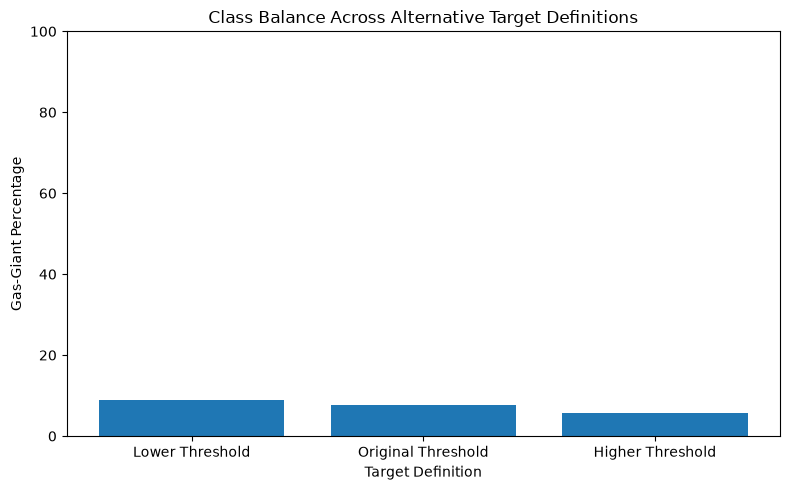

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_balance_results[
        "Threshold"
    ],
    class_balance_results[
        "Gas-Giant Percentage"
    ]
)

plt.xlabel(
    "Target Definition"
)

plt.ylabel(
    "Gas-Giant Percentage"
)

plt.title(
    "Class Balance Across Alternative Target Definitions"
)

plt.ylim(0, 100)

plt.tight_layout()

plt.show()

In [10]:
def create_rf_pipeline():

    return Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                RandomForestClassifier(
                    **final_rf_parameters
                )
            )
        ]
    )

In [11]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc"
}

alternative_target_results = []

for threshold_name, threshold_data in target_datasets.items():

    model = create_rf_pipeline()

    results = cross_validate(
        model,
        threshold_data[
            FEATURES
        ],
        threshold_data[
            "gas_giant"
        ],
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    alternative_target_results.append({
        "Threshold": threshold_name,

        "Radius Threshold":
            THRESHOLDS[
                threshold_name
            ],

        "F1":
            results[
                "test_f1"
            ].mean(),

        "F1 Std":
            results[
                "test_f1"
            ].std(),

        "ROC-AUC":
            results[
                "test_roc_auc"
            ].mean(),

        "ROC-AUC Std":
            results[
                "test_roc_auc"
            ].std()
    })

alternative_target_results = pd.DataFrame(
    alternative_target_results
)

alternative_target_results.round(4)

,Threshold,Radius Threshold,F1,F1 Std,ROC-AUC,ROC-AUC Std
0,Lower Threshold,8.0,0.4224,0.0196,0.8290,0.0091
1,Original Threshold,10.0,0.3899,0.0153,0.8252,0.0081
2,Higher Threshold,12.0,0.3763,0.0161,0.8293,0.0089


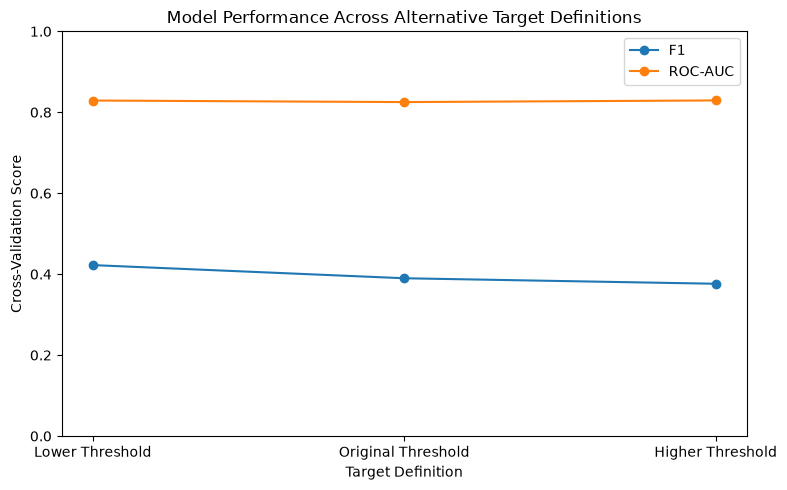

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    alternative_target_results[
        "Threshold"
    ],
    alternative_target_results[
        "F1"
    ],
    marker="o",
    label="F1"
)

plt.plot(
    alternative_target_results[
        "Threshold"
    ],
    alternative_target_results[
        "ROC-AUC"
    ],
    marker="o",
    label="ROC-AUC"
)

plt.xlabel(
    "Target Definition"
)

plt.ylabel(
    "Cross-Validation Score"
)

plt.title(
    "Model Performance Across Alternative Target Definitions"
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()

plt.show()

In [13]:
alternative_target_importance = []

for threshold_name, threshold_data in target_datasets.items():

    model = create_rf_pipeline()

    model.fit(
        threshold_data[
            FEATURES
        ],
        threshold_data[
            "gas_giant"
        ]
    )

    fitted_rf = model.named_steps[
        "model"
    ]

    for feature, importance in zip(
        FEATURES,
        fitted_rf.feature_importances_
    ):

        alternative_target_importance.append({
            "Threshold": threshold_name,
            "Feature": feature,
            "Importance": importance
        })

alternative_target_importance = pd.DataFrame(
    alternative_target_importance
)

alternative_target_importance.round(4)

,Threshold,Feature,Importance
0,Lower Threshold,st_teff,0.3857
1,Lower Threshold,st_rad,0.4082
2,Lower Threshold,st_met,0.2061
3,Original Threshold,st_teff,0.3836
4,Original Threshold,st_rad,0.4125
5,Original Threshold,st_met,0.2039
6,Higher Threshold,st_teff,0.3858
7,Higher Threshold,st_rad,0.4263
8,Higher Threshold,st_met,0.1880


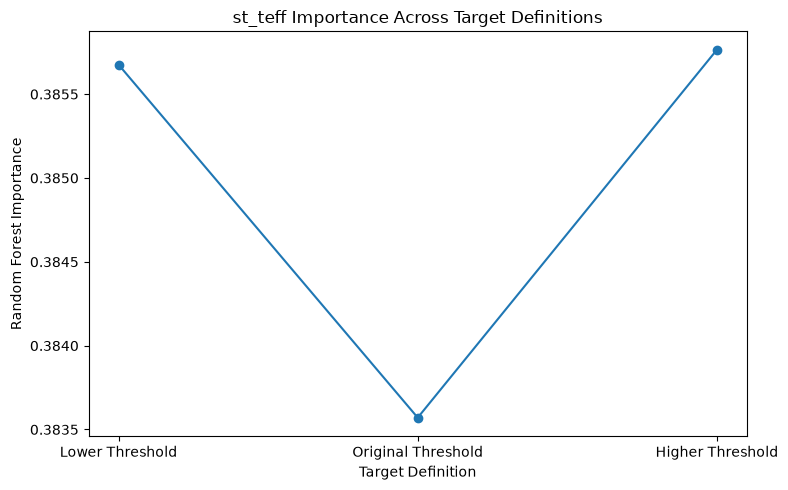

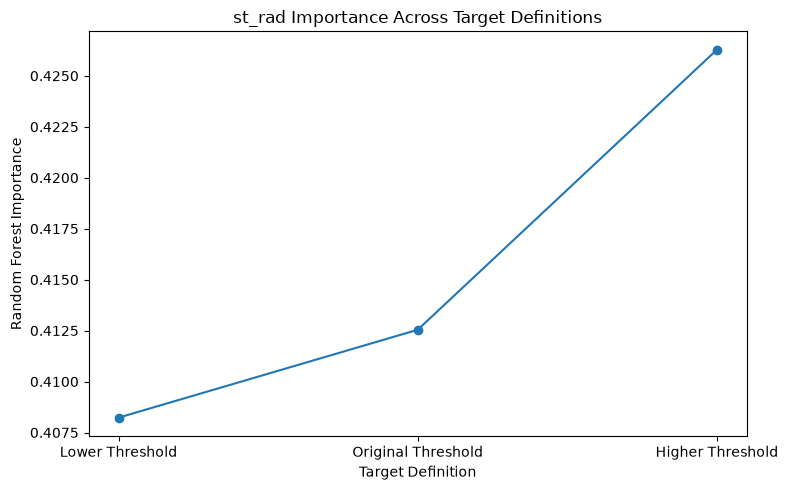

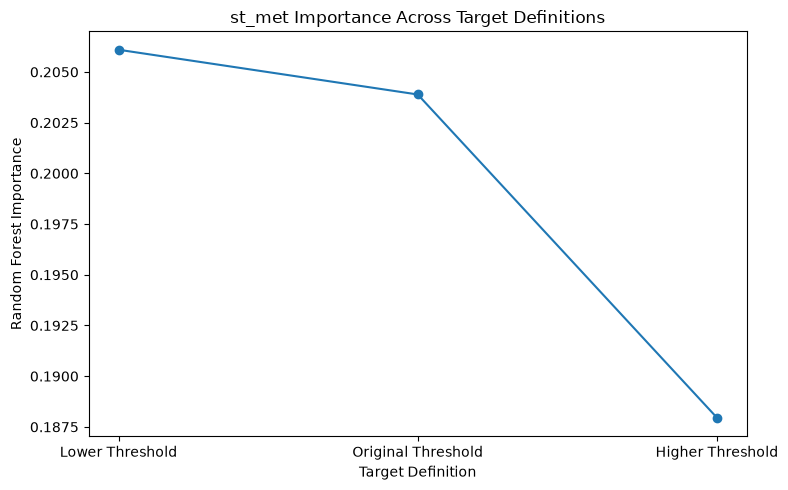

In [14]:
for feature in FEATURES:

    feature_data = alternative_target_importance[
        alternative_target_importance[
            "Feature"
        ]
        == feature
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        feature_data[
            "Threshold"
        ],
        feature_data[
            "Importance"
        ],
        marker="o"
    )

    plt.xlabel(
        "Target Definition"
    )

    plt.ylabel(
        "Random Forest Importance"
    )

    plt.title(
        f"{feature} Importance Across Target Definitions"
    )

    plt.tight_layout()

    plt.show()

# Feature Perturbation

Astronomical measurements are not perfectly exact.

This section tests whether small changes to the measured host-star properties change model predictions.

For each observation:

Original feature values
        ↓
Slightly perturbed feature values
        ↓
New predicted probability
        ↓
New predicted class

The analysis measures:

- Change in predicted probability
- Mean absolute probability change
- Classification flip rate
- Prediction stability

The perturbations are not intended to reproduce exact observational error distributions.

Instead, they provide a controlled sensitivity analysis asking:

> Would small changes in the measured stellar properties substantially alter the model's conclusions?

In [25]:
# Reconstruct the complete modeling dataset

X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze("columns")

X = pd.concat(
    [
        X_train,
        X_test
    ],
    ignore_index=True
)

y = pd.concat(
    [
        y_train,
        y_test
    ],
    ignore_index=True
)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (27540, 3)
y shape: (27540,)


In [26]:
# Original target distribution

original_class_counts = (
    y
    .value_counts()
    .sort_index()
)

original_class_proportions = (
    y
    .value_counts(
        normalize=True
    )
    .sort_index()
)

original_target_summary = pd.DataFrame({
    "Class": [
        "Non-Gas Giant",
        "Gas Giant"
    ],

    "Observations": [
        original_class_counts.get(0, 0),
        original_class_counts.get(1, 0)
    ],

    "Proportion": [
        original_class_proportions.get(0, 0),
        original_class_proportions.get(1, 0)
    ]
})

original_target_summary

,Class,Observations,Proportion
0,Non-Gas Giant,23432,0.850835
1,Gas Giant,4108,0.149165


In [27]:
PERTURBATION_LEVELS = {
    "Small": 0.01,
    "Moderate": 0.05,
    "Larger": 0.10
}

In [31]:
# Fit the fixed Random Forest model for perturbation analysis

perturbation_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "model",
            RandomForestClassifier(
                **final_rf_parameters
            )
        )
    ]
)

perturbation_model.fit(
    X,
    y
)

print(
    "Perturbation analysis model fitted successfully."
)

Perturbation analysis model fitted successfully.


In [32]:
# Prepare the data and model required for feature perturbation

FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

X_perturbation = ml_ready_dataset[
    FEATURES
].copy()

# Use the original target labels
y_perturbation = (
    ml_ready_dataset[
        "gas_giant"
    ]
    if "gas_giant" in ml_ready_dataset.columns
    else None
)

print(
    "Perturbation feature data shape:",
    X_perturbation.shape
)

Perturbation feature data shape: (39954, 3)


In [36]:
# Original predictions and probabilities
# Use the same full feature dataset as the perturbation analysis

original_probabilities = (
    perturbation_model
    .predict_proba(
        X_perturbation
    )[:, 1]
)

original_predictions = (
    perturbation_model
    .predict(
        X_perturbation
    )
)

print(
    "Original probabilities calculated."
)

print(
    "Number of original predictions:",
    len(original_probabilities)
)

Original probabilities calculated.
Number of original predictions: 39954


In [37]:
perturbation_results = []

rng = np.random.default_rng(
    RANDOM_STATE
)

for perturbation_name, perturbation_level in (
    PERTURBATION_LEVELS.items()
):

    X_perturbed = X_perturbation.copy()

    for feature in FEATURES:

        noise = rng.normal(
            loc=0,
            scale=perturbation_level,
            size=len(
                X_perturbed
            )
        )

        X_perturbed[
            feature
        ] = (
            X_perturbed[
                feature
            ]
            *
            (
                1
                +
                noise
            )
        )

    perturbed_probabilities = (
        perturbation_model
        .predict_proba(
            X_perturbed
        )[:, 1]
    )

    perturbed_predictions = (
        perturbation_model
        .predict(
            X_perturbed
        )
    )

    probability_change = (
        perturbed_probabilities
        -
        original_probabilities
    )

    absolute_probability_change = abs(
        probability_change
    )

    classification_flips = (
        perturbed_predictions
        !=
        original_predictions
    )

    perturbation_results.append({
        "Perturbation Level":
            perturbation_name,

        "Relative Perturbation":
            perturbation_level,

        "Mean Probability Change":
            probability_change.mean(),

        "Mean Absolute Probability Change":
            absolute_probability_change.mean(),

        "Median Absolute Probability Change":
            np.median(
                absolute_probability_change
            ),

        "Classification Flip Rate":
            classification_flips.mean(),

        "Prediction Stability":
            1
            -
            classification_flips.mean()
    })

perturbation_results = pd.DataFrame(
    perturbation_results
)

perturbation_results.round(4)

,Perturbation Level,Relative Perturbation,Mean Probability Change,Mean Absolute Probability Change,Median Absolute Probability Change,Classification Flip Rate,Prediction Stability
0,Small,0.01,0.0178,0.1697,0.09,0.1604,0.8396
1,Moderate,0.05,0.0544,0.2421,0.17,0.2479,0.7521
2,Larger,0.10,0.0917,0.2759,0.22,0.2948,0.7052


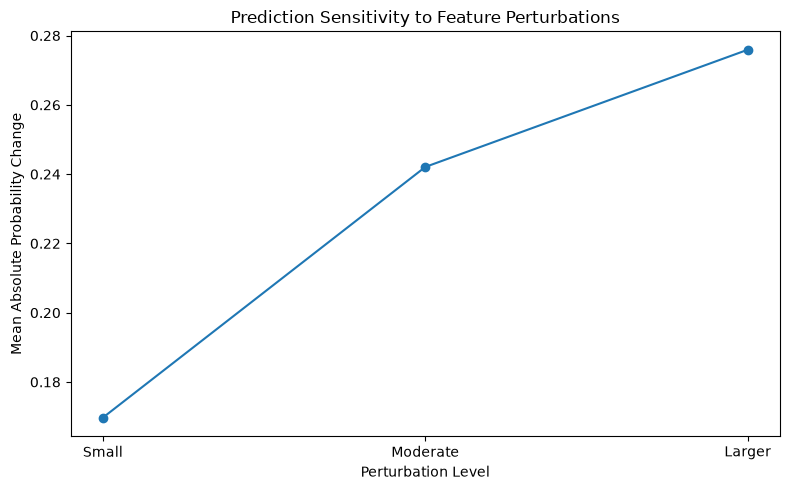

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    perturbation_results[
        "Perturbation Level"
    ],
    perturbation_results[
        "Mean Absolute Probability Change"
    ],
    marker="o"
)

plt.xlabel(
    "Perturbation Level"
)

plt.ylabel(
    "Mean Absolute Probability Change"
)

plt.title(
    "Prediction Sensitivity to Feature Perturbations"
)

plt.tight_layout()

plt.show()

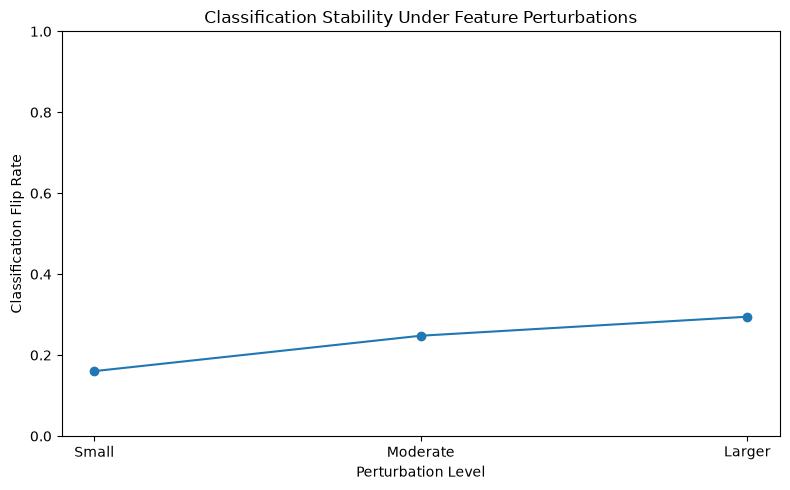

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    perturbation_results[
        "Perturbation Level"
    ],
    perturbation_results[
        "Classification Flip Rate"
    ],
    marker="o"
)

plt.xlabel(
    "Perturbation Level"
)

plt.ylabel(
    "Classification Flip Rate"
)

plt.title(
    "Classification Stability Under Feature Perturbations"
)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

# Stability Versus Prediction Confidence

The model's predicted probability provides an indication of how strongly the model favors one class over the other.

Predictions near 0.50 are relatively uncertain.

Predictions far from 0.50 are more confident.

This section tests:

> Are uncertain predictions also more sensitive to small changes in the measured stellar properties?

Predictions are divided into:

- Near-boundary predictions
- Intermediate-confidence predictions
- High-confidence predictions

The prediction stability of each group is then compared under the same feature perturbation.

In [40]:
confidence_data = pd.DataFrame({
    "Original Probability":
        original_probabilities,

    "Original Prediction":
        original_predictions
})

confidence_data[
    "Distance From 0.50"
] = abs(
    confidence_data[
        "Original Probability"
    ]
    -
    0.50
)

confidence_data[
    "Confidence Group"
] = pd.cut(
    confidence_data[
        "Distance From 0.50"
    ],
    bins=[
        -np.inf,
        0.10,
        0.25,
        np.inf
    ],
    labels=[
        "Near 0.50",
        "Intermediate",
        "Far from 0.50"
    ]
)

confidence_data[
    "Confidence Group"
].value_counts()

Confidence Group
Far from 0.50    31029
Near 0.50         4696
Intermediate      4229
Name: count, dtype: int64

In [41]:
confidence_perturbation_level = 0.05

X_confidence_perturbed = X_perturbation.copy()

rng = np.random.default_rng(
    RANDOM_STATE + 1
)

for feature in FEATURES:

    noise = rng.normal(
        loc=0,
        scale=confidence_perturbation_level,
        size=len(
            X_confidence_perturbed
        )
    )

    X_confidence_perturbed[
        feature
    ] = (
        X_confidence_perturbed[
            feature
        ]
        *
        (
            1
            +
            noise
        )
    )

perturbed_confidence_probabilities = (
    perturbation_model
    .predict_proba(
        X_confidence_perturbed
    )[:, 1]
)

perturbed_confidence_predictions = (
    perturbation_model
    .predict(
        X_confidence_perturbed
    )
)

confidence_data[
    "Perturbed Probability"
] = (
    perturbed_confidence_probabilities
)

confidence_data[
    "Absolute Probability Change"
] = abs(
    confidence_data[
        "Perturbed Probability"
    ]
    -
    confidence_data[
        "Original Probability"
    ]
)

confidence_data[
    "Classification Flip"
] = (
    perturbation_model
    .predict(
        X_confidence_perturbed
    )
    !=
    confidence_data[
        "Original Prediction"
    ]
)

In [42]:
confidence_stability = (
    confidence_data
    .groupby(
        "Confidence Group",
        observed=True
    )
    .agg(
        Observations=(
            "Original Probability",
            "count"
        ),

        Mean_Absolute_Probability_Change=(
            "Absolute Probability Change",
            "mean"
        ),

        Median_Absolute_Probability_Change=(
            "Absolute Probability Change",
            "median"
        ),

        Classification_Flip_Rate=(
            "Classification Flip",
            "mean"
        )
    )
    .reset_index()
)

confidence_stability[
    "Prediction Stability"
] = (
    1
    -
    confidence_stability[
        "Classification_Flip_Rate"
    ]
)

confidence_stability.round(4)

,Confidence Group,Observations,Mean_Absolute_Probability_Change,Median_Absolute_Probability_Change,Classification_Flip_Rate,Prediction Stability
0,Near 0.50,4696,0.1025,0.0000,0.2355,0.7645
1,Intermediate,4229,0.2260,0.1885,0.3925,0.6075
2,Far from 0.50,31029,0.2652,0.1900,0.2311,0.7689


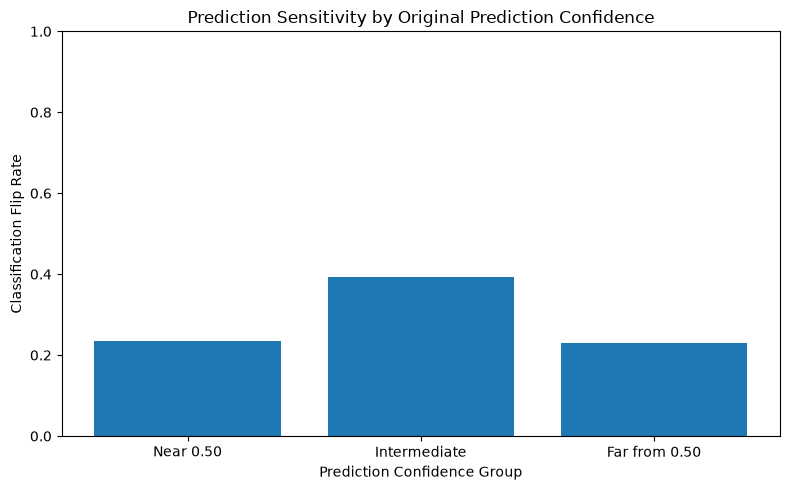

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(
    confidence_stability[
        "Confidence Group"
    ],
    confidence_stability[
        "Classification_Flip_Rate"
    ]
)

plt.xlabel(
    "Prediction Confidence Group"
)

plt.ylabel(
    "Classification Flip Rate"
)

plt.title(
    "Prediction Sensitivity by Original Prediction Confidence"
)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

## Final Scientific Interpretation

This notebook tested whether the conclusions of the machine-learning analysis remain stable under reasonable changes to the scientific assumptions.

First, alternative planetary-radius thresholds were used to redefine the gas-giant class. Model performance, class balance, and feature importance were then compared across the alternative definitions.

Second, small perturbations were applied to the measured host-star properties. The resulting changes in predicted probabilities and classifications were measured to evaluate prediction stability.

Finally, prediction stability was compared across different levels of model confidence.

The results should be interpreted using three questions:

1. **Target-definition robustness**  
   Do similar predictive patterns remain when the gas-giant boundary changes slightly?

2. **Measurement sensitivity**  
   Do small changes in the measured stellar properties substantially alter predictions?

3. **Confidence-stability relationship**  
   Are predictions near the classification boundary more sensitive to perturbations than high-confidence predictions?

If the broad feature patterns and scientific conclusions remain similar across alternative target definitions, this supports robustness to the chosen classification boundary.

If small feature perturbations produce relatively small probability changes and low classification flip rates, this supports prediction stability.

If low-confidence predictions are more sensitive to perturbations than high-confidence predictions, this would provide an important scientific interpretation of model uncertainty.

These analyses do not prove that the model is robust to all possible definitions or all real observational uncertainties. They test only the specific alternative thresholds and perturbation scenarios examined here.